# 01 - CV Transformer Training and 
CV Extraction


In [9]:
# Requires: pip install -e .

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from graph_utils import calc_p_ratio_box
from course_project.config import ExperimentConfig
from course_project.runner import run_graph_cv_experiment
from course_project.data import load_dataset
from course_project.graph import build_graph
from course_project.hessian import collect_cv_lambda5_points
from course_project.models import create_model, resolve_model_inputs


In [10]:
import random
import shutil

seed = 876543
force_train = False
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

fixed_params = {
    'hidden_size': 160,
    'learning_rate': 1e-5,
}

time_lag_steps = 0
time_lag_weight = 0
CVs = 4
token_sizes = (160, 60, CVs)
full_dataset_path = '../data/2340_dePablo_networks_OOL_undirected.pt'

# Data split
train_count = 30
val_count = 30

all_sims = load_dataset(full_dataset_path)
train_sims = all_sims[:train_count]
val_sims = all_sims[train_count:train_count + val_count]
test_sims = all_sims[train_count + val_count:]

print('source dataset:', full_dataset_path)
print('train sims:', len(train_sims), 'val sims:', len(val_sims), 'test sims:', len(test_sims))

common_cfg = dict(
    dataset_path=full_dataset_path,
    train_count=train_count,
    val_count=val_count,
    output_root='../results',
    pos_dim=2,
    history=1,
    limit=50,
    n_layers=2,
    learning_rate_decay=0.997,
    weight_decay=0.0,
    epochs=12,
    val_every=2,
    rollout_every=0,
    cv_eval_every=2,
    freeze_normalizers_after_epoch=10,
    device='cuda',
)

cfg_cv_transformer = ExperimentConfig(
    run_name='cv_transformer_single',
    model_type='cv_transformer',
    seed=seed,
    learning_rate=float(fixed_params['learning_rate']),
    hidden_size=int(fixed_params['hidden_size']),
    model_extras={
        'num_mlp': 3,
        'transformer_layers': 1,
        'transformer_heads': 1,
        'transformer_dropout': 0.001,
        'use_local_skip': True,
        'token_sizes': token_sizes,
        'time_lag_steps': int(time_lag_steps),
        'time_lag_weight': float(time_lag_weight),
    },
    **common_cfg,
)

run_dir = Path(cfg_cv_transformer.output_root) / cfg_cv_transformer.run_name
selection_json = Path(common_cfg['output_root']) / 'cv_transformer_best_cv_selection.json'
best_ckpt_out = Path(common_cfg['output_root']) / 'cv_transformer_best_cv_checkpoint.pt'

need_train = force_train or not (run_dir / 'train_stats.pt').exists() or not selection_json.exists() or not best_ckpt_out.exists()
if need_train:
    metrics = run_graph_cv_experiment(cfg_cv_transformer)
    stats = torch.load(run_dir / 'train_stats.pt', map_location='cpu', weights_only=False)
    epochs = np.asarray(stats['epoch'], dtype=int)
    cv_fit_r2 = np.asarray(stats['cv_fit_r2'], dtype=float)
    best_idx = int(np.nanargmax(cv_fit_r2))
    best_epoch = int(epochs[best_idx])
    best_score = float(cv_fit_r2[best_idx])
    best_ckpt = run_dir / 'rollout_checkpoints' / f'epoch_{best_epoch:04d}.pt'
    shutil.copy2(best_ckpt, best_ckpt_out)
    selection = {
        'run_name': str(cfg_cv_transformer.run_name),
        'best_cv_fit_r2': best_score,
        'best_cv_epoch': best_epoch,
        'checkpoint_path': str(best_ckpt),
        'saved_checkpoint_path': str(best_ckpt_out),
        'fixed_params': fixed_params,
    }
    selection_json.write_text(json.dumps(selection, indent=2))
    print('single run:', cfg_cv_transformer.run_name)
    print('best cv_fit_r2:', best_score, 'epoch:', best_epoch)
    print('saved best checkpoint:', best_ckpt_out)
    print('saved selection:', selection_json)
else:
    print('using existing CV run from', run_dir)
    print('using existing selection from', selection_json)


source dataset: ../data/2340_dePablo_networks_OOL_undirected.pt
train sims: 30 val sims: 30 test sims: 40
using existing CV run from ../results/cv_transformer_single
using existing selection from ../results/cv_transformer_best_cv_selection.json


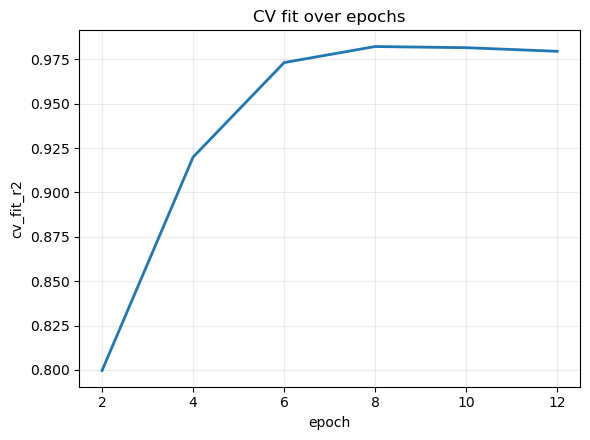

best cv_fit_r2= 0.9821866007601752 at epoch 8


In [11]:
# CV-fit over epochs.
run_dir = Path(cfg_cv_transformer.output_root) / cfg_cv_transformer.run_name
stats = torch.load(run_dir / 'train_stats.pt', map_location='cpu', weights_only=False)

epochs = np.asarray(stats['epoch'], dtype=int)
cv_fit_r2 = np.asarray(stats['cv_fit_r2'], dtype=float)
mask_cv = np.isfinite(cv_fit_r2)

fig, ax = plt.subplots(figsize=(6.0, 4.5))
ax.plot(epochs[mask_cv], cv_fit_r2[mask_cv], '-', linewidth=2.0, color='tab:blue')
ax.set_xlabel('epoch')
ax.set_ylabel('cv_fit_r2')
ax.grid(alpha=0.25)
ax.set_title('CV fit over epochs')
plt.tight_layout()
plt.show()

best_i = int(np.nanargmax(cv_fit_r2))
print('best cv_fit_r2=', float(cv_fit_r2[best_i]), 'at epoch', int(epochs[best_i]))


In [12]:
# Load model from the saved best CV-fit checkpoint.
output_root = Path(cfg_cv_transformer.output_root)
selection = json.loads((output_root / 'cv_transformer_best_cv_selection.json').read_text())

run_dir = output_root / selection['run_name']
cfg_dict = json.loads((run_dir / 'config.json').read_text())
cfg_loaded = ExperimentConfig(**cfg_dict)

device = cfg_loaded.device

all_sims = load_dataset(cfg_loaded.dataset_path)
val_data = all_sims[cfg_loaded.train_count:cfg_loaded.train_count + cfg_loaded.val_count]
test_data = all_sims[cfg_loaded.train_count + cfg_loaded.val_count:]

init_frames = [val_data[0][i].to(device) for i in range(cfg_loaded.history + 1)]
init_graph = build_graph(input_graphs=init_frames).to(device)

model = create_model(
    model_type=cfg_loaded.model_type,
    init_graph=init_graph,
    pos_dim=cfg_loaded.pos_dim,
    hidden_size=cfg_loaded.hidden_size,
    n_layers=cfg_loaded.n_layers,
    extras=cfg_loaded.model_extras,
).to(device)

best_ckpt = Path(selection['saved_checkpoint_path'])
model.load_checkpoint(str(best_ckpt))

model.eval()
model.freeze_normalizers = True
for p in model.parameters():
    p.requires_grad = False
model_inputs_cls = resolve_model_inputs(cfg_loaded.model_type)

print('Loaded model:', cfg_loaded.model_type, 'device=', device)
print('Run dir:', run_dir)
print('Loaded best CV checkpoint:', best_ckpt)
print('best cv_fit_r2:', float(selection['best_cv_fit_r2']), 'epoch:', int(selection['best_cv_epoch']))
print('effective token sizes:', cfg_loaded.model_extras['token_sizes'])
print('validation sims:', len(val_data), '| test sims:', len(test_data))



Loaded model: cv_transformer device= cuda
Run dir: ../results/cv_transformer_single
Loaded best CV checkpoint: ../results/cv_transformer_best_cv_checkpoint.pt
best cv_fit_r2: 0.9821866007601752 epoch: 8
effective token sizes: [160, 60, 4]
validation sims: 30 | test sims: 40


In [13]:
# Extract trajectory-level CV summaries and final p-ratio for VAL and TEST.
def extract_cv_summary(sims, split_name):
    rows = []
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            n_local = len(sim) - 1
            final_pr = float(calc_p_ratio_box(sim, -1))
            cv_values = []
            for t in range(cfg_loaded.history, n_local):
                frames = [sim[i].to(device) for i in range(t - cfg_loaded.history, t + 1)]
                if t > 0:
                    prev_pos = sim[t - 1].to(device).x[:, : cfg_loaded.pos_dim]
                    cur_pos = frames[-1].x[:, : cfg_loaded.pos_dim]
                    frames[-1].vel_state = cur_pos - prev_pos
                input_graph = build_graph(frames).to(device)
                cv = model.extract_cv(input_graph, is_training=False).squeeze(0).detach().cpu().numpy()
                cv_values.append(np.asarray(cv, dtype=float).reshape(-1))

            cv_mean = np.mean(np.stack(cv_values, axis=0), axis=0)
            row = {
                'split': split_name,
                'sim_idx': sim_idx,
                'num_frames_used': len(cv_values),
                'final_p_ratio': final_pr,
            }
            for i, value in enumerate(cv_mean, start=1):
                row[f'cv_{i}'] = float(value)
            rows.append(row)
    return pd.DataFrame(rows).sort_values('sim_idx').reset_index(drop=True)


def extract_cv_frames(sims, split_name):
    rows = []
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            n_local = len(sim) - 1
            for t in range(cfg_loaded.history, n_local):
                frames = [sim[i].to(device) for i in range(t - cfg_loaded.history, t + 1)]
                if t > 0:
                    prev_pos = sim[t - 1].to(device).x[:, : cfg_loaded.pos_dim]
                    cur_pos = frames[-1].x[:, : cfg_loaded.pos_dim]
                    frames[-1].vel_state = cur_pos - prev_pos
                input_graph = build_graph(frames).to(device)
                cv = model.extract_cv(input_graph, is_training=False).squeeze(0).detach().cpu().numpy()
                row = {'split': split_name, 'sim_idx': sim_idx, 't': int(t)}
                for i, value in enumerate(np.asarray(cv, dtype=float).reshape(-1), start=1):
                    row[f'cv_{i}'] = float(value)
                rows.append(row)
    return pd.DataFrame(rows)


def fit_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    coeff = np.polyfit(x, y, deg=1)
    y_hat = coeff[0] * x + coeff[1]
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    return float(1.0 - ss_res / ss_tot)


def cv_pratio_table(df, split_name):
    rows = []
    cv_cols = [c for c in df.columns if c.startswith('cv_')]
    y = df['final_p_ratio'].to_numpy(dtype=float)
    for col in cv_cols:
        x = df[col].to_numpy(dtype=float)
        rows.append({
            'split': split_name,
            'cv': col,
            'pearson_r': float(np.corrcoef(x, y)[0, 1]),
            'spearman_r': float(df[col].corr(df['final_p_ratio'], method='spearman')),
            'fit_r2': fit_r2(x, y),
        })
    out = pd.DataFrame(rows)
    out['abs_pearson_r'] = out['pearson_r'].abs()
    return out.sort_values('abs_pearson_r', ascending=False).reset_index(drop=True)


df_val = extract_cv_summary(val_data, 'val')
df_test = extract_cv_summary(test_data, 'test')

val_cv_table = cv_pratio_table(df_val, 'val')
test_cv_table = cv_pratio_table(df_test, 'test')

best_cv_col = str(val_cv_table.iloc[0]['cv'])
best_cv_idx = int(best_cv_col.split('_')[1]) - 1

print('best CV on val:', best_cv_col, '(index:', best_cv_idx, ')')
print(val_cv_table[['cv', 'pearson_r', 'spearman_r', 'fit_r2']])


best CV on val: cv_3 (index: 2 )
     cv  pearson_r  spearman_r    fit_r2
0  cv_3  -0.991053   -0.985762  0.982187
1  cv_4  -0.960483   -0.968854  0.922528
2  cv_2  -0.913310   -0.914127  0.834135
3  cv_1   0.407935    0.450056  0.166411


using CV pair: cv_1 and cv_3 | validation |r|= 0.403585230943262


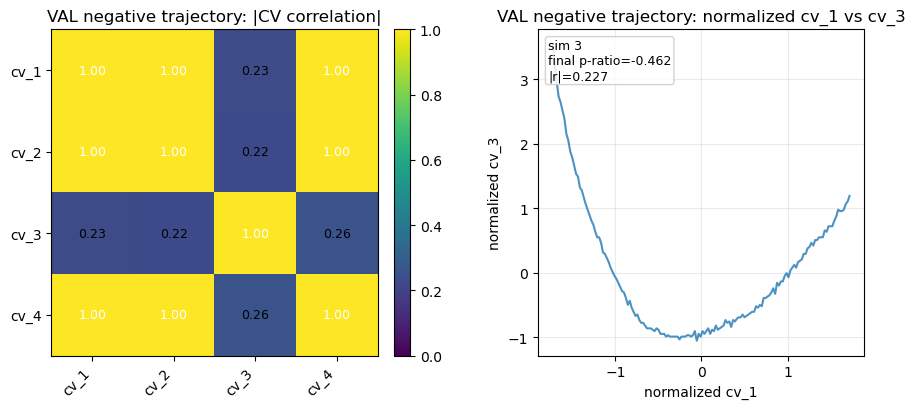

saved: ../results/cv_transformer_single/cv_transformer_val_single_negative_cv_view.png


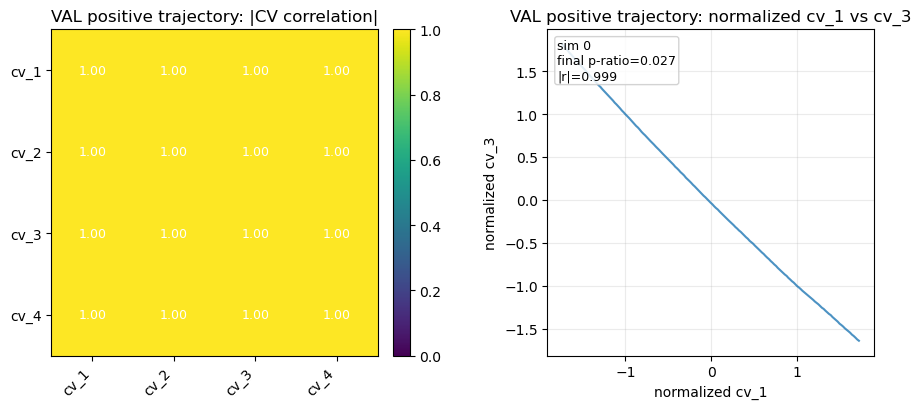

saved: ../results/cv_transformer_single/cv_transformer_val_single_positive_cv_view.png


In [14]:
# Single-trajectory VAL CV view: one negative and one positive final p-ratio trajectory.
frame_rows = []
with torch.no_grad():
    for sim_idx, sim in enumerate(val_data):
        for t in range(cfg_loaded.history, len(sim) - 1):
            frames = [sim[i].to(device) for i in range(t - cfg_loaded.history, t + 1)]
            if t > 0:
                prev_pos = sim[t - 1].to(device).x[:, : cfg_loaded.pos_dim]
                cur_pos = frames[-1].x[:, : cfg_loaded.pos_dim]
                frames[-1].vel_state = cur_pos - prev_pos
            input_graph = build_graph(frames).to(device)
            cv = model.extract_cv(input_graph, is_training=False).squeeze(0).detach().cpu().numpy()
            row = {'sim_idx': sim_idx, 't': t}
            for i, value in enumerate(np.asarray(cv, dtype=float).reshape(-1)):
                row[f'cv_{i + 1}'] = float(value)
            frame_rows.append(row)

frame_cv_df = pd.DataFrame(frame_rows)
cv_cols = [c for c in frame_cv_df.columns if c.startswith('cv_')]
assert len(cv_cols) >= 2
c1 = cv_cols[0]
val_corr = np.abs(frame_cv_df[cv_cols].corr(method='pearson').to_numpy(dtype=float))
c1_idx = cv_cols.index(c1)
other_idx = [i for i in range(len(cv_cols)) if i != c1_idx]
c2_idx = min(other_idx, key=lambda i: val_corr[c1_idx, i])
c2 = cv_cols[c2_idx]
print('using CV pair:', c1, 'and', c2, '| validation |r|=', float(val_corr[c1_idx, c2_idx]))

val_pr = df_val[['sim_idx', 'final_p_ratio']]
neg_sim_idx = int(val_pr.loc[val_pr['final_p_ratio'] < 0, 'sim_idx'].iloc[0])
pos_sim_idx = int(val_pr.loc[val_pr['final_p_ratio'] > 0, 'sim_idx'].iloc[0])

def normalize_pair(sub, xcol, ycol):
    x = sub[xcol].to_numpy(dtype=float)
    y = sub[ycol].to_numpy(dtype=float)
    x = (x - x.mean()) / (x.std() + 1e-8)
    y = (y - y.mean()) / (y.std() + 1e-8)
    return x, y

def plot_one_sim(sim_idx, out_name, panel_title):
    sub = frame_cv_df[frame_cv_df['sim_idx'] == int(sim_idx)].reset_index(drop=True)
    pr = float(val_pr.loc[val_pr['sim_idx'] == int(sim_idx), 'final_p_ratio'].iloc[0])
    corr = np.abs(sub[cv_cols].corr(method='pearson').to_numpy(dtype=float))
    r = abs(float(sub[c1].corr(sub[c2], method='pearson')))
    x, y = normalize_pair(sub, c1, c2)

    fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.2))
    im = axes[0].imshow(corr, vmin=0.0, vmax=1.0, cmap='viridis')
    axes[0].set_xticks(range(len(cv_cols)))
    axes[0].set_yticks(range(len(cv_cols)))
    axes[0].set_xticklabels(cv_cols, rotation=45, ha='right')
    axes[0].set_yticklabels(cv_cols)
    axes[0].set_title(f'{panel_title}: |CV correlation|')
    for i in range(len(cv_cols)):
        for j in range(len(cv_cols)):
            axes[0].text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=9, color='white' if corr[i, j] > 0.55 else 'black')
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    axes[1].plot(x, y, color='tab:blue', alpha=0.8, linewidth=1.5)
    axes[1].set_title(f'{panel_title}: normalized {c1} vs {c2}')
    axes[1].text(
        0.03, 0.97,
        f'sim {sim_idx}\nfinal p-ratio={pr:.3f}\n|r|={r:.3f}',
        transform=axes[1].transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor='0.8'),
    )
    axes[1].set_xlabel(f'normalized {c1}')
    axes[1].set_ylabel(f'normalized {c2}')
    axes[1].grid(alpha=0.25)
    axes[1].set_box_aspect(1)

    fig.tight_layout()
    out_path = run_dir / out_name
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('saved:', out_path)

plot_one_sim(neg_sim_idx, 'cv_transformer_val_single_negative_cv_view.png', 'VAL negative trajectory')
plot_one_sim(pos_sim_idx, 'cv_transformer_val_single_positive_cv_view.png', 'VAL positive trajectory')


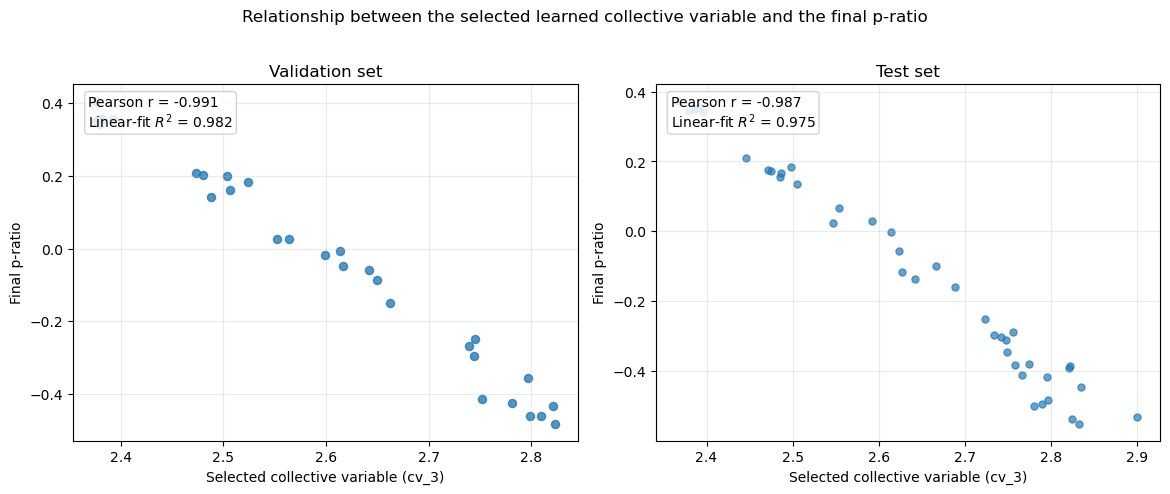

best checkpoint epoch: 8
saved: ../results/cv_transformer_single/cv_transformer_val_best_cv_vs_pratio.csv
saved: ../results/cv_transformer_single/cv_transformer_test_best_cv_vs_pratio.csv
saved: ../results/cv_transformer_single/cv_transformer_test_all_cv_vs_pratio.csv
saved: ../results/cv_transformer_single/cv_transformer_best_cv_val_test_scatter.png


In [15]:
# Report-style scatter of the selected CV against final p-ratio on VAL and TEST.
x_val = df_val[best_cv_col].to_numpy(dtype=float)
y_val = df_val['final_p_ratio'].to_numpy(dtype=float)
r_val = float(np.corrcoef(x_val, y_val)[0, 1])
r2_val = fit_r2(x_val, y_val)

x_test = df_test[best_cv_col].to_numpy(dtype=float)
y_test = df_test['final_p_ratio'].to_numpy(dtype=float)
r_test = float(np.corrcoef(x_test, y_test)[0, 1])
r2_test = fit_r2(x_test, y_test)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.8))

axes[0].scatter(x_val, y_val, s=34, alpha=0.78)
axes[0].set_title('Validation set')
axes[0].set_xlabel(f'Selected collective variable ({best_cv_col})')
axes[0].set_ylabel('Final p-ratio')
axes[0].text(
    0.03, 0.97,
    f'Pearson r = {r_val:.3f}\nLinear-fit $R^2$ = {r2_val:.3f}',
    transform=axes[0].transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='0.8'),
)
axes[0].grid(alpha=0.25)

axes[1].scatter(x_test, y_test, s=26, alpha=0.68)
axes[1].set_title('Test set')
axes[1].set_xlabel(f'Selected collective variable ({best_cv_col})')
axes[1].set_ylabel('Final p-ratio')
axes[1].text(
    0.03, 0.97,
    f'Pearson r = {r_test:.3f}\nLinear-fit $R^2$ = {r2_test:.3f}',
    transform=axes[1].transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='0.8'),
)
axes[1].grid(alpha=0.25)

fig.suptitle(
    'Relationship between the selected learned collective variable and the final p-ratio',
    y=1.02,
)
fig.tight_layout()

val_csv = run_dir / 'cv_transformer_val_best_cv_vs_pratio.csv'
test_csv = run_dir / 'cv_transformer_test_best_cv_vs_pratio.csv'
test_table_csv = run_dir / 'cv_transformer_test_all_cv_vs_pratio.csv'
plot_png = run_dir / 'cv_transformer_best_cv_val_test_scatter.png'

df_val[['sim_idx', best_cv_col, 'final_p_ratio']].to_csv(val_csv, index=False)
df_test[['sim_idx', best_cv_col, 'final_p_ratio']].to_csv(test_csv, index=False)
test_cv_table.to_csv(test_table_csv, index=False)
fig.savefig(plot_png, dpi=180, bbox_inches='tight')

plt.show()

print('best checkpoint epoch:', int(selection['best_cv_epoch']))
print('saved:', val_csv)
print('saved:', test_csv)
print('saved:', test_table_csv)
print('saved:', plot_png)


In [ ]:
# Test-set Hessian check: selected best CV against lambda5.
hessian_rows = collect_cv_lambda5_points(
    model=model,
    sims=test_sims,
    history=cfg_loaded.history,
    pos_dim=cfg_loaded.pos_dim,
    device=device,
    cv_index=best_cv_idx,
)
hessian_df = pd.DataFrame(hessian_rows)
hessian_df = hessian_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['cv', 'lambda5']).reset_index(drop=True)

x = hessian_df['cv'].to_numpy(dtype=float)
y = hessian_df['lambda5'].to_numpy(dtype=float)
pearson_r = float(np.corrcoef(x, y)[0, 1])

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.scatter(x, y, s=14, alpha=0.45)
ax.set_xlabel(f'Selected collective variable ({best_cv_col})')
ax.set_ylabel('Hessian slow mode $\lambda_5$')
ax.set_title('Test set: selected CV against $\lambda_5$')
ax.grid(alpha=0.2)
ax.text(0.03, 0.97, f'Pearson r = {pearson_r:.3f}\npoints = {len(hessian_df)}', transform=ax.transAxes, va='top', ha='left', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='0.8'))
plt.tight_layout()
plt.show()

hessian_df.head()
